Steps:
1. Load raw CSV
2. Type conversions & trip end filling
3. Rename to snake_case
4. Impute lat/lon from census tract
5. Impute census tract from lat/lon (lookup)
6. Drop rows with no spatial data
7. Payment type cleanup
8. Company standardization
9. Duplicate check
10. Remove invalid trips (any zero/below-threshold)
11. Consistency & logic checks
12. Absolute outlier filtering
13. Save cleaned parquet
14. ID remapping + compact parquet
15. Time features from trip_start
16. Cyclic encoding (sin/cos)
17. Electronic payment fee detection + save compact parquet
18. Save removed rows

To run this notebook it is necessary to have the Taxi_Trip data downloaded as csv and names as "<i>Taxi_Trips_(2024-).csv.</i>"

## 0) Setup and data loading
First all necessary packages are imported, paths are setup and data is then loaded.

In [1]:
import pandas as pd
import numpy as np
import polars as pl
import os
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

PROJECT = Path(os.getcwd()).parent
DATA_DIR = PROJECT / "data"

CSV_PATH = DATA_DIR / "Taxi_Trips_(2024-).csv"
OUTPUT_CLEAN = DATA_DIR / "Taxi_Trips_cleaned.parquet"
OUTPUT_COMPACT = DATA_DIR / "Taxi_Trips_compact.parquet"
OUTPUT_TRIP_ID_MAP = DATA_DIR / "trip_id_mapping.csv"
OUTPUT_TAXI_ID_MAP = DATA_DIR / "taxi_id_mapping.csv"
OUTPUT_REMOVED = DATA_DIR / "Removed_Rows.parquet"
OUTPUT_NO_SPATIAL = DATA_DIR / "No_Spatial_Value.parquet"
OUTPUT_COMPANIES = DATA_DIR / "company_names_after_cleaning.csv"

removed_frames = []

def flag_and_remove(df, mask, reason):
    n = mask.sum()
    if n == 0:
        return df
    removed = df.loc[mask].copy()
    removed["removal_reason"] = reason
    removed_frames.append(removed)
    print(f"  Removed {n:,} rows: {reason}")
    return df[~mask].reset_index(drop=True)

print("Setup complete.")
print(f"Project: {PROJECT}")
print(f"Data dir: {DATA_DIR}")



Setup complete.
Project: c:\Users\Claus Hack\Documents\AAA_project_team_5
Data dir: c:\Users\Claus Hack\Documents\AAA_project_team_5\data


In [2]:
data = pl.read_csv(CSV_PATH, low_memory=False, schema_overrides={"Trip Seconds": pl.String}) # do not remove casting to string!!!
original_rows = data.shape[0]
statistics = [("Original row count", original_rows)]
print(f"Loaded {data.shape[0]:,} rows, {data.shape[1]} columns")
print(f'DATA_DIR: {data.dtypes}')

print('Example columns:')
display(data.head(2))
data = data.lazy()

Loaded 15,406,960 rows, 23 columns
DATA_DIR: [String, String, String, String, String, String, Int64, Int64, Int64, Int64, String, String, String, String, String, String, String, String, String, String, String, String, String]
Example columns:


Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tips,Tolls,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…","""05/01/2026 12:00:00 AM""","""05/01/2026 12:00:00 AM""","""398""","""1,16""",null,null,32,8,"""$6,75""","""$2,00""","""$0,00""","""$1,00""","""$10,25""","""Credit Card""","""Blue Ribbon Taxi Association""","""41,878865584""","""-87,625192142""","""POINT (-87.6251921424 41.87886…","""41,899602111""","""-87,633308037""","""POINT (-87.6333080367 41.89960…"
"""ec94d6d233061d415f0c89cb9222e9…","""b3ee94a13b61037620cbbfc6a4a106…","""05/01/2026 12:00:00 AM""","""05/01/2026 12:15:00 AM""","""780""","""2""",null,null,8,28,"""$9,50""","""$4,00""","""$0,00""","""$2,00""","""$15,50""","""Credit Card""","""Transit Administrative Center …","""41,899602111""","""-87,633308037""","""POINT (-87.6333080367 41.89960…","""41,874005383""","""-87,66351755""","""POINT (-87.6635175498 41.87400…"


# 1) Type casting and renaming
Next step is to convert the types to the correct data types as we can see above that not all columns are numeric.

In [3]:
# Casting
money_cols = ["Fare", "Tips", "Tolls", "Extras",  "Trip Total"]

data = data.with_columns(
    pl.col(money_cols)
    .str.replace("$", "", literal=True)
    .str.replace(",", ".", literal=True)
    .cast(pl.Float64, strict=False),
).with_columns( # Miles to float
    pl.col('Trip Miles').str.replace(",", ".", literal=True).cast(pl.Float64, strict=False),
    pl.col("Trip Seconds").str.replace(r"\.", "")
).with_columns( # timestamp casting
    pl.col("Trip Start Timestamp").str.to_datetime("%m/%d/%Y %I:%M:%S %p").alias("Trip Start Timestamp"),
    pl.col("Trip End Timestamp").str.to_datetime("%m/%d/%Y %I:%M:%S %p").alias("Trip End Timestamp"),
    (pl.col("Trip Seconds").cast(pl.Int64) * 1000).cast(pl.Duration("ms")).alias("Trip Seconds")    
). with_columns([
    pl.col("Pickup Centroid Latitude").str.replace(",", ".").cast(pl.Float64),
    pl.col("Pickup Centroid Longitude").str.replace(",", ".").cast(pl.Float64),
    pl.col("Dropoff Centroid Latitude").str.replace(",", ".").cast(pl.Float64),
    pl.col("Dropoff Centroid Longitude").str.replace(",", ".").cast(pl.Float64)]
).with_columns(
    pl.col("Pickup Census Tract").cast(pl.Int64, strict=False),
    pl.col("Dropoff Census Tract").cast(pl.Int64, strict=False)
)
data = data.collect()
display(data.head(2))

Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tips,Tolls,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
str,str,datetime[μs],datetime[μs],duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00,2026-05-01 00:00:00,6m 38s,1.16,null,null,32,8,6.75,2.0,0.0,1.0,10.25,"""Credit Card""","""Blue Ribbon Taxi Association""",41.878866,-87.625192,"""POINT (-87.6251921424 41.87886…",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…"
"""ec94d6d233061d415f0c89cb9222e9…","""b3ee94a13b61037620cbbfc6a4a106…",2026-05-01 00:00:00,2026-05-01 00:15:00,13m,2.0,null,null,8,28,9.5,4.0,0.0,2.0,15.5,"""Credit Card""","""Transit Administrative Center …",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…",41.874005,-87.663518,"""POINT (-87.6635175498 41.87400…"


In [4]:
snake_map = {
    "Trip ID": "trip_id",
    "Taxi ID": "taxi_id",
    "Trip Start Timestamp": "trip_start",
    "Trip End Timestamp": "trip_end",
    "Trip Seconds": "trip_seconds",
    "Trip Miles": "trip_miles",
    "Pickup Census Tract": "pickup_census_tract",
    "Dropoff Census Tract": "dropoff_census_tract",
    "Pickup Community Area": "pickup_community_area",
    "Dropoff Community Area": "dropoff_community_area",
    "Fare": "fare_usd",
    "Tips": "tips_usd",
    "Tolls": "tolls_usd",
    "Extras": "extras_usd",
    "Trip Total": "trip_total_usd",
    "Payment Type": "payment_type",
    "Company": "company",
    "Pickup Centroid Latitude": "pickup_lat",
    "Pickup Centroid Longitude": "pickup_lon",
    "Pickup Centroid Location": "pickup_location",
    "Dropoff Centroid Latitude": "dropoff_lat",
    "Dropoff Centroid Longitude": "dropoff_lon",
    "Dropoff Centroid  Location": "dropoff_location",
}
# Polars: returns a new DataFrame, so reassign
data = data.rename(snake_map)

print(f"Renamed {len(snake_map)} columns.")
print(f'New column names: {data.columns}')

Renamed 23 columns.
New column names: ['trip_id', 'taxi_id', 'trip_start', 'trip_end', 'trip_seconds', 'trip_miles', 'pickup_census_tract', 'dropoff_census_tract', 'pickup_community_area', 'dropoff_community_area', 'fare_usd', 'tips_usd', 'tolls_usd', 'extras_usd', 'trip_total_usd', 'payment_type', 'company', 'pickup_lat', 'pickup_lon', 'pickup_location', 'dropoff_lat', 'dropoff_lon', 'dropoff_location']


# 3) Missing values
In this chapter missing values are handled.

In [5]:
missing_counts = data.select([
    pl.col(col).is_null().sum().alias(col) for col in data.columns
])
print("Missing values by column:")
display(missing_counts)

Missing values by column:


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,345,2936,146,8547337,8751654,429216,1366538,33658,31816,31830,31854,33707,0,0,421354,421354,421354,1285413,1285413,1285413


## 3.1) Missing time values
Missing time values can appear in trip_start, trip_end and trip_seconds. We can see that the start time is always available but trip_end and trip seconds are incomplete. Further we noticed that the trip_end timestamp is not very reliable. In the diagram below you can see that the recalculated trip seconds are very fixed while the actual trip seconds provided by the dataset are much more distributed. 

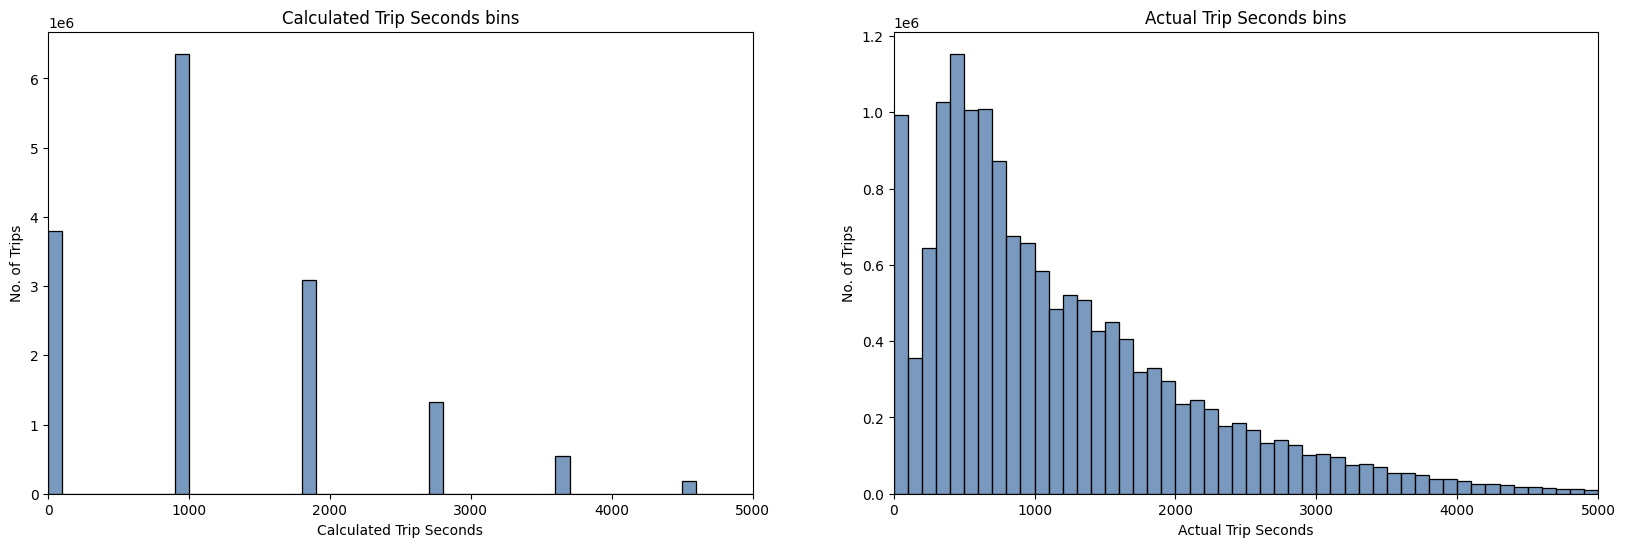

In [6]:
# distribution plot of calulated_trip_seconds
data = data.with_columns(
    (pl.col("trip_end") - pl.col("trip_start")).dt.total_seconds().alias("calculated_trip_seconds")
)
len(data)
fix, ax = plt.subplots(1, 2, figsize=(20, 6))
calculated_seconds = data.get_column("calculated_trip_seconds").drop_nulls().to_numpy()
actual_seconds = data.get_column("trip_seconds").dt.total_seconds().drop_nulls().to_numpy()

sns.histplot(calculated_seconds, bins=50, binrange=(0, 5000), ax=ax[0], color="#4C78A8", edgecolor="black")
ax[0].set_title("Calculated Trip Seconds bins")
ax[0].set_xlabel("Calculated Trip Seconds")
ax[0].set_ylabel("No. of Trips")
ax[0].set_xlim(0, 5000)

sns.histplot(actual_seconds, bins=50, binrange=(0, 5000), ax=ax[1], color="#4C78A8", edgecolor="black")
ax[1].set_title("Actual Trip Seconds bins")
ax[1].set_xlabel("Actual Trip Seconds")
ax[1].set_ylabel("No. of Trips")
ax[1].set_xlim(0, 5000)
plt.show()

To solve the issue, we decided to recalculate the trip_end entirely based on the actual trip seconds. The number of missing trip seconds is low and we can also see some trips where the trip took more than 24 hours, e.g. see belows print.

In [7]:
missing_trip_seconds = data.filter(pl.col("trip_seconds").is_null()).shape[0]
print(f"Number of rows with missing trip_seconds: {missing_trip_seconds:,}")

display(data.filter( pl.col("trip_seconds").is_null() &
    pl.col("trip_start").is_not_null() &
    pl.col("trip_end").is_not_null()).head(3))

Number of rows with missing trip_seconds: 2,936


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location,calculated_trip_seconds
str,str,datetime[μs],datetime[μs],duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str,i64
"""f2db7abd79bd6ba165e3c8edf463ae…","""7e3afd37c79b617eafd3a5a20a403a…",2026-04-30 11:45:00,2026-05-02 09:00:00,null,7.08,null,null,69,69,19.75,0.0,0.0,0.0,19.75,"""Cash""","""Blue Ribbon Taxi Association""",41.763247,-87.616134,"""POINT (-87.6161341112 41.76324…",41.763247,-87.616134,"""POINT (-87.6161341112 41.76324…",162900
"""87578924c7c509795be19b90d0cddf…","""7cb0514cc412166ac972e884eb9b85…",2026-04-29 16:00:00,2026-04-30 18:15:00,null,0.0,null,null,null,null,9.0,0.0,0.0,0.0,9.0,"""Cash""","""City Service""",null,null,null,null,null,null,94500
"""0e868a0daf654c1f7e5145dbb8538c…","""cdb5dabbf347707495209b50041932…",2026-04-29 14:30:00,2026-04-29 14:30:00,null,0.0,null,null,71,71,null,null,null,null,null,"""Cash""","""Flash Cab""",41.744205,-87.656306,"""POINT (-87.6563059862 41.74420…",41.744205,-87.656306,"""POINT (-87.6563059862 41.74420…",0


In [8]:
length = len(data)

data = data.filter(pl.col("trip_seconds").is_not_null())
print(f"Dropped {length - len(data):,} rows with missing trip_seconds.")
statistics.append(("Removed rows with missing trip_seconds", length - len(data)))

Dropped 2,936 rows with missing trip_seconds.


In [9]:
print('Before recalculation of trip_end:')
display(data.head(1))
data = data.with_columns(
        (pl.col("trip_start") + pl.col("trip_seconds").cast(pl.Duration("ms"))).alias("trip_end")
).drop("calculated_trip_seconds")
print('\nAfter recalculation of trip_end:')
display(data.head(1))

Before recalculation of trip_end:


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location,calculated_trip_seconds
str,str,datetime[μs],datetime[μs],duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str,i64
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00,2026-05-01 00:00:00,6m 38s,1.16,null,null,32,8,6.75,2.0,0.0,1.0,10.25,"""Credit Card""","""Blue Ribbon Taxi Association""",41.878866,-87.625192,"""POINT (-87.6251921424 41.87886…",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…",0



After recalculation of trip_end:


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location
str,str,datetime[μs],datetime[ms],duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00,2026-05-01 00:06:38,6m 38s,1.16,null,null,32,8,6.75,2.0,0.0,1.0,10.25,"""Credit Card""","""Blue Ribbon Taxi Association""",41.878866,-87.625192,"""POINT (-87.6251921424 41.87886…",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…"


## 3.2) Missing location values
Location values are all latitude, longitude, census tracts, locations, and community areas. 

It was first tried to interpolate the values based on other trips data. So if either census or coordinations were given to interpolate based on the other records values but this seemed to be difficult this nearly interpolated none of the records. We assume that this is due to most of the trips missing data comes from the privacy ensurance of the data. This means similar trips have the same missing information.

Additional methods to interpolate may also be not worth the work as the number of rows which can be interpolated is quite low. Most of the cases if one is missing, all is missing.

Therefore, we decided to drop the rows which do not have pickup locations available. The destination/dropoff is not as relevant because we want to predict the demand of taxis in an area, so how many taxis are estimated to start a trip from the area and not where the trip ends.

### 3.2.1) Latitude and longitude

In [10]:
# number of rows with missing lat/lon but valid census tract
mask_pu = (
    pl.col("pickup_lat").is_null() &
    pl.col("pickup_lon").is_null() &
    pl.col("pickup_census_tract").is_not_null()
)
mask_do = (
    pl.col("dropoff_lat").is_null() &
    pl.col("dropoff_lon").is_null() &
    pl.col("dropoff_census_tract").is_not_null()
)
print(f"Rows with missing pickup lat/lon but valid census tract: {data.filter(mask_pu).shape[0]}")
print(f"Rows with missing dropoff lat/lon but valid census tract: {data.filter(mask_do).shape[0]}")

Rows with missing pickup lat/lon but valid census tract: 2015
Rows with missing dropoff lat/lon but valid census tract: 16393


In [11]:
missing_counts = data.select([
    pl.col(col).is_null().sum().alias(col) for col in ['pickup_census_tract', 'pickup_lat', 'pickup_lon', 
                                                       'dropoff_census_tract', 'dropoff_lat', 'dropoff_lon', 
                                                       'pickup_location', 'dropoff_location', 'pickup_community_area', 'dropoff_community_area']
])
print("Missing values by column:")
display(missing_counts)

Missing values by column:


pickup_census_tract,pickup_lat,pickup_lon,dropoff_census_tract,dropoff_lat,dropoff_lon,pickup_location,dropoff_location,pickup_community_area,dropoff_community_area
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
8545544,421108,421108,8749649,1284705,1284705,421108,1284705,428955,1365809


In [12]:
data = data.drop_nulls(subset=["pickup_lat", "pickup_lon"])
statistics.append(("Removed rows with missing lat/lon", original_rows - data.shape[0]))

In [13]:
statistics

[('Original row count', 15406960),
 ('Removed rows with missing trip_seconds', 2936),
 ('Removed rows with missing lat/lon', 424044)]

In [14]:
df = data.to_pandas()

In [15]:
del data

### 3.2.2) Census Tracts
Latitude and longitude coordinations are more precise than census tracts. Still for the spatial analysis these are relevant and offer additional information. As many are missing (see below) they are imputed using a dataset from US Government about census tracts (https://www.census.gov/cgi-bin/geo/shapefiles/index.php?year=2024&layergroup=Census+Tracts)

In [16]:
# number of records with missing census tract but with valid lat/lon
mask_pu = (
    df['pickup_lat'].notna() &
    df['pickup_lon'].notna() &
    df['pickup_census_tract'].isna()
)
mask_do = (
    df['dropoff_lat'].notna() &
    df['dropoff_lon'].notna() &
    df['dropoff_census_tract'].isna()
)
print(f"After imputation - Rows with missing census tract but valid pickup lat/lon: {mask_pu.sum()}")
print(f"After imputation - Rows with missing census tract but valid dropoff lat/lon: {mask_do.sum()}")

After imputation - Rows with missing census tract but valid pickup lat/lon: 8126451
After imputation - Rows with missing census tract but valid dropoff lat/lon: 7369830


In [17]:
df.head(1)

,trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location
0,f48c3b6c5c3bb929f585a167a9fd1f7280eafaf2,85c39e068db414d181c6252a89fd822afc2e169a9a9e85...,2026-05-01,2026-05-01 00:06:38,0 days 00:06:38,1.16,NaN,NaN,32.0,8.0,...,1.0,10.25,Credit Card,Blue Ribbon Taxi Association,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)


In [18]:
pickup_remaining = (
    df["pickup_census_tract"].isna() & df["pickup_lat"].notna() & df["pickup_lon"].notna()
).sum()
dropoff_remaining = (
    df["dropoff_census_tract"].isna() & df["dropoff_lat"].notna() & df["dropoff_lon"].notna()
).sum()

print("Missing census tracts after spatial fill:")
print(f"  pickup:  {pickup_remaining:,}")
print(f"  dropoff: {dropoff_remaining:,}")

Missing census tracts after spatial fill:
  pickup:  8,126,451
  dropoff: 7,369,830


In [19]:
# Prompt: I want to fill the missing census tracts to ensure by using the shp file. Using the available latitude and longitude from the trips, either pickup and dropoff to fill the missing dropoff_census_tract and pickup_census_tract.
census_gdf = gpd.read_file("../data/tl_2024_17_tract/tl_2024_17_tract.shp")
import geopandas as gpd

# Build a tract lookup from the census shapefile that is already loaded above.
tract_col_candidates = ["GEOID", "geoid", "GEOID20", "TRACTCE", "tractce"]
tract_col = next((col for col in tract_col_candidates if col in census_gdf.columns), None)
if tract_col is None:
    raise KeyError(f"Could not find a census tract id column in census_gdf: {list(census_gdf.columns)}")

tract_gdf = census_gdf[[tract_col, "geometry"]].copy().to_crs(epsg=4326)
tract_gdf[tract_col] = pd.to_numeric(tract_gdf[tract_col], errors="coerce").astype("Int64")


def fill_missing_tracts(frame, target_col, lat_col, lon_col):
    mask = frame[target_col].isna() & frame[lat_col].notna() & frame[lon_col].notna()
    if not mask.any():
        return 0

    points = gpd.GeoDataFrame(
        frame.loc[mask].copy(),
        geometry=gpd.points_from_xy(frame.loc[mask, lon_col], frame.loc[mask, lat_col]),
        crs="EPSG:4326",
    )

    joined = gpd.sjoin(points, tract_gdf[[tract_col, "geometry"]], how="left", predicate="within")
    frame.loc[mask, target_col] = joined[tract_col].to_numpy()
    return int(mask.sum())


pickup_filled = fill_missing_tracts(df, "pickup_census_tract", "pickup_lat", "pickup_lon")
dropoff_filled = fill_missing_tracts(df, "dropoff_census_tract", "dropoff_lat", "dropoff_lon")

print(f"Filled pickup census tracts from coordinates: {pickup_filled:,}")
print(f"Filled dropoff census tracts from coordinates: {dropoff_filled:,}")
print(
    "Remaining missing pickup tracts with coordinates: "
    f"{((df['pickup_census_tract'].isna()) & df['pickup_lat'].notna() & df['pickup_lon'].notna()).sum():,}"
)
print(
    "Remaining missing dropoff tracts with coordinates: "
    f"{((df['dropoff_census_tract'].isna()) & df['dropoff_lat'].notna() & df['dropoff_lon'].notna()).sum():,}"
)

df.head(3)

Filled pickup census tracts from coordinates: 8,126,451
Filled dropoff census tracts from coordinates: 7,369,830
Remaining missing pickup tracts with coordinates: 0
Remaining missing dropoff tracts with coordinates: 0


,trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location
0,f48c3b6c5c3bb929f585a167a9fd1f7280eafaf2,85c39e068db414d181c6252a89fd822afc2e169a9a9e85...,2026-05-01,2026-05-01 00:06:38,0 days 00:06:38,1.16,1.703132e+10,1.703108e+10,32.0,8.0,...,1.0,10.25,Credit Card,Blue Ribbon Taxi Association,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,ec94d6d233061d415f0c89cb9222e94e65667326,b3ee94a13b61037620cbbfc6a4a106d2ad628a06f0988f...,2026-05-01,2026-05-01 00:13:00,0 days 00:13:00,2.00,1.703108e+10,1.703183e+10,8.0,28.0,...,2.0,15.50,Credit Card,Transit Administrative Center Inc,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.874005,-87.663518,POINT (-87.6635175498 41.874005383)
2,e96d8e910cc577d191447dfdf5dc59a6a5ddc9f5,0c758d798a3980ff73e5f1a334db48be8aa4271db5d6cf...,2026-05-01,2026-05-01 00:00:36,0 days 00:00:36,0.18,1.703156e+10,1.703156e+10,56.0,56.0,...,0.0,3.50,Cash,Sun Taxi,41.792592,-87.769615,POINT (-87.7696154528 41.7925923603),41.792592,-87.769615,POINT (-87.7696154528 41.7925923603)


In [20]:
pickup_remaining = (
    df["pickup_census_tract"].isna() & df["pickup_lat"].notna() & df["pickup_lon"].notna()
).sum()
dropoff_remaining = (
    df["dropoff_census_tract"].isna() & df["dropoff_lat"].notna() & df["dropoff_lon"].notna()
).sum()

print("Missing census tracts after spatial fill:")
print(f"  pickup:  {pickup_remaining:,}")
print(f"  dropoff: {dropoff_remaining:,}")

Missing census tracts after spatial fill:
  pickup:  0
  dropoff: 0


### 3.2.3) Trip distance

In [21]:
# convert to polars
data = pl.from_pandas(df)
del df
data.head(3)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location
str,str,datetime[μs],datetime[ms],duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00,2026-05-01 00:06:38,6m 38s,1.16,1.7031e10,1.7031e10,32.0,8.0,6.75,2.0,0.0,1.0,10.25,"""Credit Card""","""Blue Ribbon Taxi Association""",41.878866,-87.625192,"""POINT (-87.6251921424 41.87886…",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…"
"""ec94d6d233061d415f0c89cb9222e9…","""b3ee94a13b61037620cbbfc6a4a106…",2026-05-01 00:00:00,2026-05-01 00:13:00,13m,2.0,1.7031e10,1.7032e10,8.0,28.0,9.5,4.0,0.0,2.0,15.5,"""Credit Card""","""Transit Administrative Center …",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…",41.874005,-87.663518,"""POINT (-87.6635175498 41.87400…"
"""e96d8e910cc577d191447dfdf5dc59…","""0c758d798a3980ff73e5f1a334db48…",2026-05-01 00:00:00,2026-05-01 00:00:36,36s,0.18,1.7032e10,1.7032e10,56.0,56.0,3.5,0.0,0.0,0.0,3.5,"""Cash""","""Sun Taxi""",41.792592,-87.769615,"""POINT (-87.7696154528 41.79259…",41.792592,-87.769615,"""POINT (-87.7696154528 41.79259…"


In [22]:
missing_counts = data.select([
    pl.col(col).is_null().sum().alias(col) for col in data.columns
])
print("Missing values by column:")
display(missing_counts)

Missing values by column:


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,118,0,989100,7847,1084134,31358,30000,30012,30034,31401,0,0,0,0,0,1003535,1003535,1003535


In [23]:
data.head(1)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location
str,str,datetime[μs],datetime[ms],duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00,2026-05-01 00:06:38,6m 38s,1.16,1.7031e10,1.7031e10,32.0,8.0,6.75,2.0,0.0,1.0,10.25,"""Credit Card""","""Blue Ribbon Taxi Association""",41.878866,-87.625192,"""POINT (-87.6251921424 41.87886…",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…"


# 4) Duplicates
One taxi can only drive one trip at a time, so if combination of a taxi_id and a trip_start returns more than one record it is a duplicate.
As we cannot say in general which of these trips is correct, we drop both.

In [24]:
# check for duplicates in trip_id
before = len(data)
data = data.unique(subset=["taxi_id", 'trip_start'], keep="none")
dups = before - len(data)
print(f"Total rows: {before:,}, Unique trip_ids: {len(data):,}, Duplicates: {dups:,}")
statistics.append(("Removed duplicate trip_id rows", dups))

Total rows: 14,982,916, Unique trip_ids: 13,760,726, Duplicates: 1,222,190


# 5) Ilogical data
In this part any values which do not make sense are removed.

## 5.1) Negative values
Starting with negative values in the following columns, as these do not make sense with a negative value:
`trip_seconds, trip_miles, fare_usd, tips_usd, tolls_usd, extras_usd, and trip_total_usd`

In [25]:
length = len(data)
print(f'Length before removing invalid records: {length:,}')
data = data.filter(
    (pl.col("trip_seconds") >= 0) &
    (pl.col("trip_miles") >= 0) &
    (pl.col("fare_usd") >= 0) &
    (pl.col("tips_usd") >= 0) &
    (pl.col("tolls_usd") >= 0) &
    (pl.col("extras_usd") >= 0) &
    (pl.col("trip_total_usd") >= 0)
)
print(f"Rows with negative trip_seconds, trip_miles, fare_usd, tips_usd, tolls_usd, extras_usd, and trip_total_usd removed: {length - len(data):,}")

print(f"\nRemaining after invalid trip removal: {len(data):,}")

Length before removing invalid records: 13,760,726
Rows with negative trip_seconds, trip_miles, fare_usd, tips_usd, tolls_usd, extras_usd, and trip_total_usd removed: 6,221

Remaining after invalid trip removal: 13,754,505


## 5.2) Extreme values
Extreme high or low value do not make sense depending on the column. 
1. Trips with less than 60 seconds duration are dropped because we assume these are too short. Also for the prediction these may be confusing, as the taxi is not actually occupied.
2. Trips with very short distances are also dropped because of the same reason above.
3. Trips with exactly zero fare are dropped. We assume that for our client, these trips are irrelevant as no money was earned.
4. Trips, where the <b>average</b> speed was over 100 mph (~160 km/h)

In [26]:
length = len(data)
data = data
data = data.filter(
    (pl.col('trip_seconds') > (60*1000)) & 
    (pl.col('trip_miles') > 0.01) & 
    (pl.col('fare_usd') > 0)
)
print(f"Rows removed (reason 1, 2, and 3): {length - len(data):,}")

data = data.with_columns(
    (pl.col("trip_miles") / (pl.col("trip_seconds").cast(pl.Float64) / 3_600_000)).alias("average_speed_mph")
).filter(pl.col('average_speed_mph') < 100)
print(f"Rows with implausible average speed (>100 mph) removed: {length - len(data):,}")

print(f"\nRemaining after removing extreme values: {len(data):,}")
statistics.append(("Removed extreme values", length - len(data)))

Rows removed (reason 1, 2, and 3): 1,040,867
Rows with implausible average speed (>100 mph) removed: 1,041,850

Remaining after removing extreme values: 12,712,655


In [27]:
data.head(3)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location,average_speed_mph
str,str,datetime[μs],datetime[ms],duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str,f64
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00,2026-05-01 00:06:38,6m 38s,1.16,1.7031e10,1.7031e10,32.0,8.0,6.75,2.0,0.0,1.0,10.25,"""Credit Card""","""Blue Ribbon Taxi Association""",41.878866,-87.625192,"""POINT (-87.6251921424 41.87886…",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…",10.492462
"""ec94d6d233061d415f0c89cb9222e9…","""b3ee94a13b61037620cbbfc6a4a106…",2026-05-01 00:00:00,2026-05-01 00:13:00,13m,2.0,1.7031e10,1.7032e10,8.0,28.0,9.5,4.0,0.0,2.0,15.5,"""Credit Card""","""Transit Administrative Center …",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…",41.874005,-87.663518,"""POINT (-87.6635175498 41.87400…",9.230769
"""e4d6e70bb24a040d511144a0b9f827…","""137d4f780c3823fdc5f26cec160a8c…",2026-05-01 00:00:00,2026-05-01 00:02:26,2m 26s,0.41,1.7032e10,1.7032e10,28.0,28.0,8.5,1.2,0.0,0.0,10.2,"""Mobile""","""5 Star Taxi""",41.874005,-87.663518,"""POINT (-87.6635175498 41.87400…",41.874005,-87.663518,"""POINT (-87.6635175498 41.87400…",10.109589


# 6) Outlier Filtering
Below diagram shows the distribution of trip_seconds, trip_miles and fare. 

Extreme long trips of mouch more than 17 miles are only very few. Further the trip duration is usually below 1 hour. Also the fare is below 70 US$. 

We decided to only remove trips which are extordinary long. This means trips taking over 12 hours and over 200 miles.

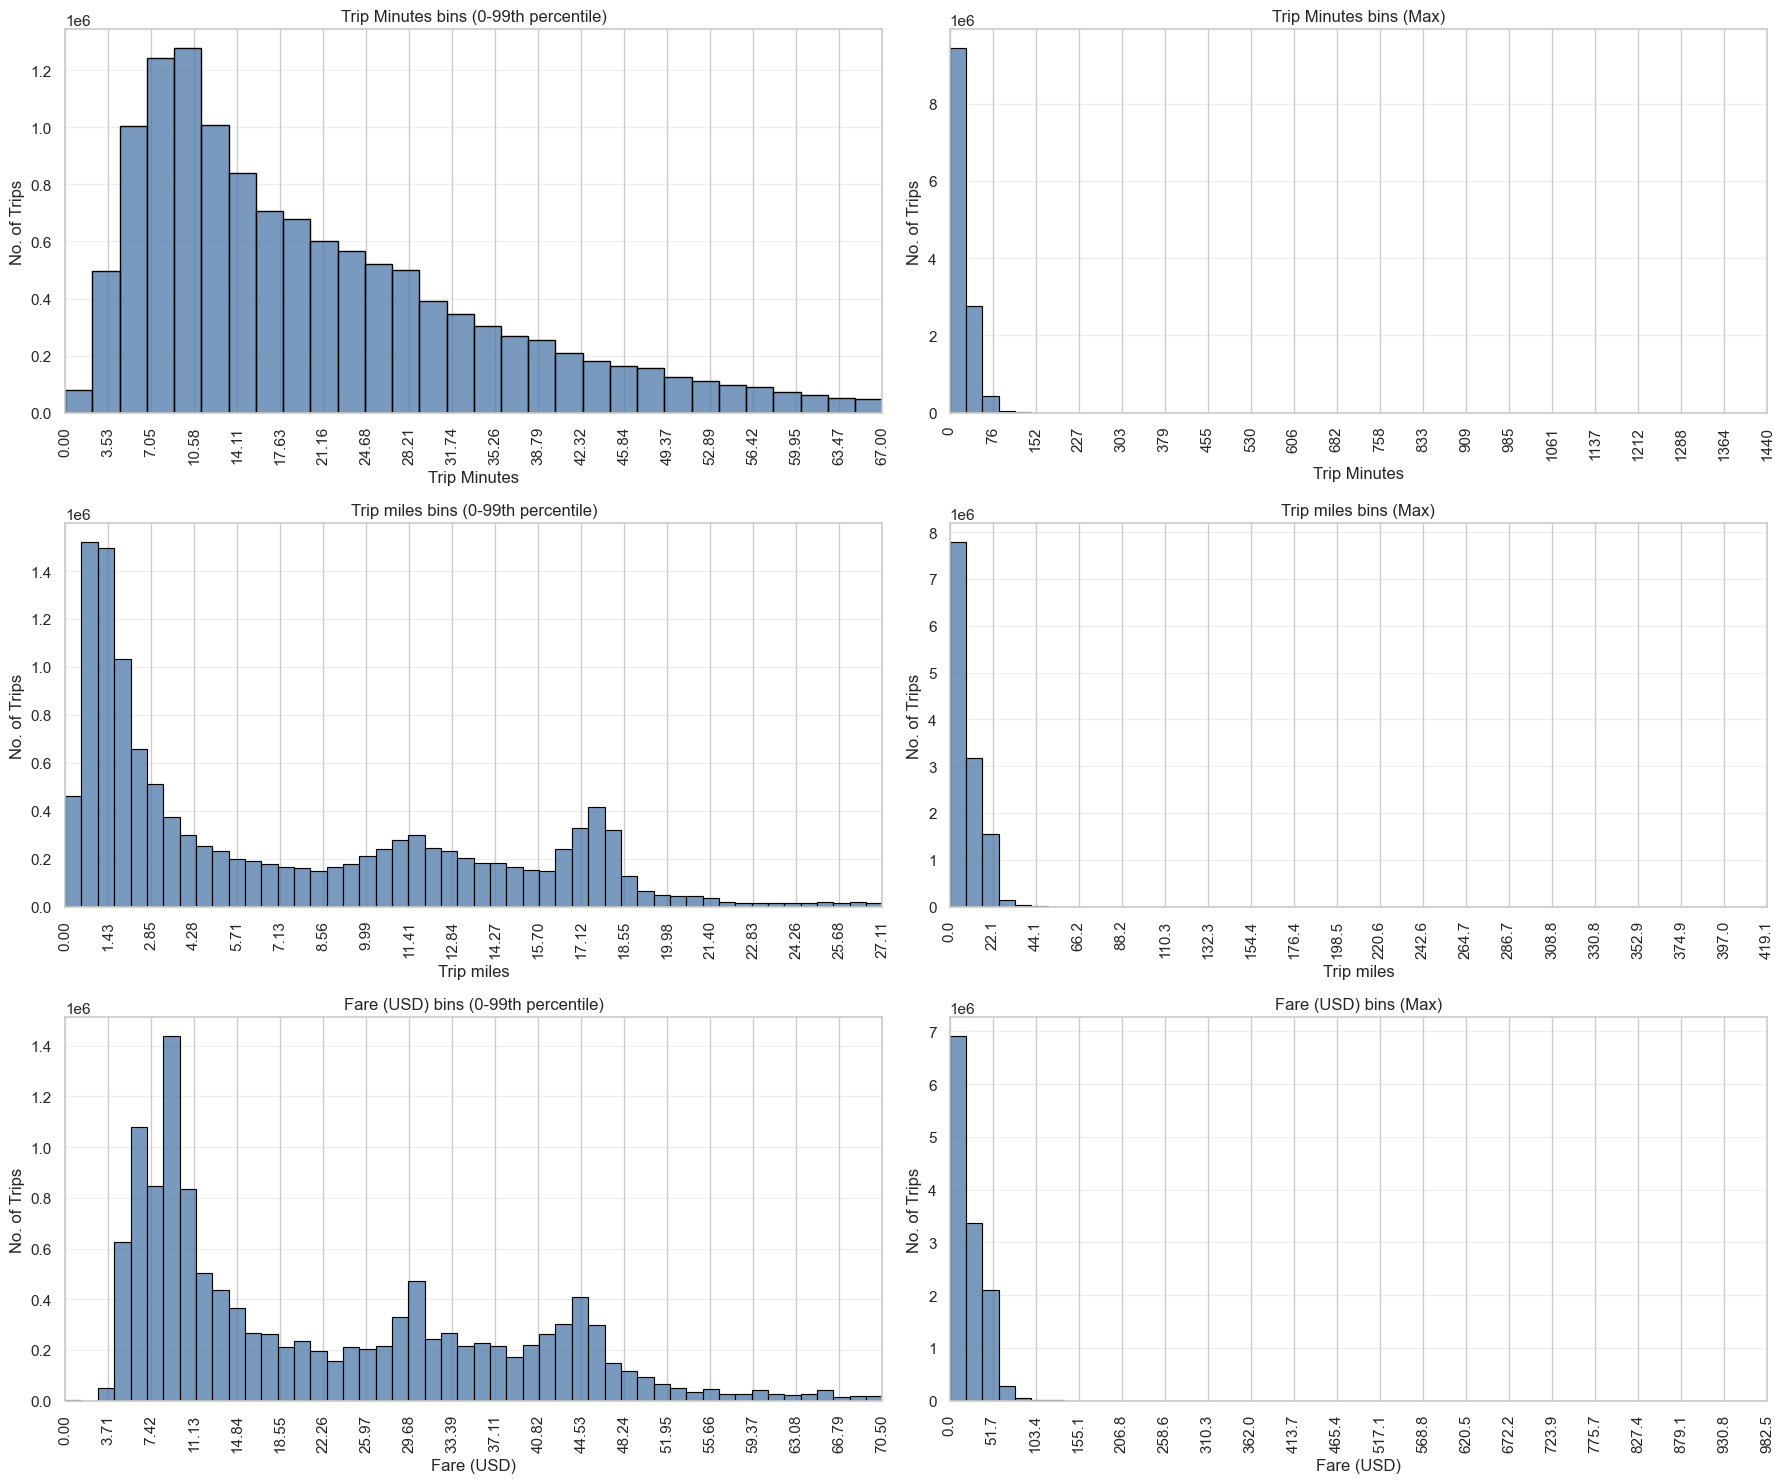

In [28]:
plot_df = data.select(["trip_seconds", "trip_miles", "fare_usd"])
plot_df = plot_df.with_columns([
    (pl.col("trip_seconds").dt.total_seconds()/60).alias("trip_seconds"),
])


num_ticks = 20
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# --- 1. TRIP SECONDS ---
trip_seconds = plot_df.get_column("trip_seconds").drop_nulls().to_numpy()
trip_seconds_pct = float(np.quantile(trip_seconds, 0.98))
trip_seconds_max = float(trip_seconds.max())

# Left Plot (Percentile)
sns.histplot(
    trip_seconds,
    bins=30,
    binrange=(0, trip_seconds_pct),
    ax=axes[0, 0],
    color="#4C78A8",
    edgecolor="black",
)
axes[0, 0].set_title("Trip Minutes bins (0-99th percentile)")
axes[0, 0].set_xlabel("Trip Minutes")
axes[0, 0].set_ylabel("No. of Trips")
axes[0, 0].set_xlim(0, trip_seconds_pct)
axes[0, 0].set_xticks(np.linspace(0, trip_seconds_pct, num_ticks))
axes[0, 0].tick_params(axis="x", rotation=90)
axes[0, 0].grid(axis="y", alpha=0.3)

# Right Plot (Max)
sns.histplot(
    trip_seconds,
    bins=50,
    binrange=(0, trip_seconds_max),
    ax=axes[0, 1],
    color="#4C78A8",
    edgecolor="black",
)
axes[0, 1].set_title("Trip Minutes bins (Max)")
axes[0, 1].set_xlabel("Trip Minutes")
axes[0, 1].set_ylabel("No. of Trips")
axes[0, 1].set_xlim(0, trip_seconds_max)
axes[0, 1].set_xticks(np.linspace(0, trip_seconds_max, num_ticks))
axes[0, 1].tick_params(axis="x", rotation=90)
axes[0, 1].grid(axis="y", alpha=0.3)


# --- 2. TRIP MILES ---
trip_miles = plot_df.get_column("trip_miles").drop_nulls().to_numpy()
trip_miles_pct = float(np.quantile(trip_miles, 0.99))
trip_miles_max = float(trip_miles.max())

# Left Plot (Percentile)
sns.histplot(
    trip_miles,
    bins=50,
    binrange=(0, trip_miles_pct),
    ax=axes[1, 0],
    color="#4C78A8",
    edgecolor="black",
)
axes[1, 0].set_title("Trip miles bins (0-99th percentile)")
axes[1, 0].set_xlabel("Trip miles")
axes[1, 0].set_ylabel("No. of Trips")
axes[1, 0].set_xlim(0, trip_miles_pct)
axes[1, 0].set_xticks(np.linspace(0, trip_miles_pct, num_ticks))
axes[1, 0].tick_params(axis="x", rotation=90)
axes[1, 0].grid(axis="y", alpha=0.3)

# Right Plot (Max)
sns.histplot(
    trip_miles,
    bins=50,
    binrange=(0, trip_miles_max),
    ax=axes[1, 1],
    color="#4C78A8",
    edgecolor="black",
)
axes[1, 1].set_title("Trip miles bins (Max)")
axes[1, 1].set_xlabel("Trip miles")
axes[1, 1].set_ylabel("No. of Trips")
axes[1, 1].set_xlim(0, trip_miles_max)
axes[1, 1].set_xticks(np.linspace(0, trip_miles_max, num_ticks))
axes[1, 1].tick_params(axis="x", rotation=90)
axes[1, 1].grid(axis="y", alpha=0.3)


# --- 3. FARE USD ---
fare_usd = plot_df.get_column("fare_usd").drop_nulls().to_numpy()
fare_usd_pct = float(np.quantile(fare_usd, 0.99))
fare_usd_max = float(fare_usd.max())

# Left Plot (Percentile)
sns.histplot(
    fare_usd,
    bins=50,
    binrange=(0, fare_usd_pct),
    ax=axes[2, 0],
    color="#4C78A8",
    edgecolor="black",
)
axes[2, 0].set_title("Fare (USD) bins (0-99th percentile)")
axes[2, 0].set_xlabel("Fare (USD)")
axes[2, 0].set_ylabel("No. of Trips")
axes[2, 0].set_xlim(0, fare_usd_pct)
axes[2, 0].set_xticks(np.linspace(0, fare_usd_pct, num_ticks))
axes[2, 0].tick_params(axis="x", rotation=90)
axes[2, 0].grid(axis="y", alpha=0.3)

# Right Plot (Max)
sns.histplot(
    fare_usd,
    bins=50,
    binrange=(0, fare_usd_max),
    ax=axes[2, 1],
    color="#4C78A8",
    edgecolor="black",
)
axes[2, 1].set_title("Fare (USD) bins (Max)")
axes[2, 1].set_xlabel("Fare (USD)")
axes[2, 1].set_ylabel("No. of Trips")
axes[2, 1].set_xlim(0, fare_usd_max)
axes[2, 1].set_xticks(np.linspace(0, fare_usd_max, num_ticks))
axes[2, 1].tick_params(axis="x", rotation=90)
axes[2, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
length = len(data)

data = data.filter((pl.col('trip_miles') < 200) & (pl.col('trip_seconds') < 3*60*60*1000))

print(f"Rows removed with trip_miles < 200 and trip_seconds < 3 hours: {length - len(data):,}")
statistics.append(("Removed rows with trip_miles < 200 and trip_seconds < 3 hours", length - len(data)))

Rows removed with trip_miles < 200 and trip_seconds < 3 hours: 10,884


# 7) Column cleanup
## 7.1) Column: Payment Type
Cleanup the payment type column

Payment types: 7


payment_type,count
str,u32
"""no charge""",19944
"""unknown""",452819
"""mobile""",3156281
"""dispute""",4159
"""prcard""",1594824
"""cash""",2704087
"""credit card""",4769657


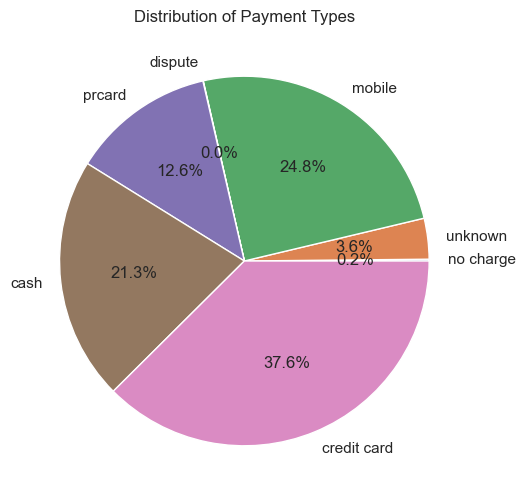

In [30]:
data = data.with_columns(
    pl.col("payment_type")
    .str.to_lowercase()
    .str.strip_chars()
    .str.replace_all(r"\s+", " ", literal=False)
)

# 2. Print unique count
print(f"Payment types: {data['payment_type'].n_unique()}")

# 3. Print value counts
vc = data["payment_type"].value_counts()
display(vc)

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style("whitegrid")
ax.pie(vc["count"], labels=vc["payment_type"], autopct='%1.1f%%')
plt.title("Distribution of Payment Types")
plt.show()

## 7.2) Column: Company 
Cleanup the company column

Unique companies: 38


company,count
str,u32
"""flash cab""",2695722
"""taxicab insurance agency llc""",1729257
"""sun taxi""",1488835
"""city service""",1345559
"""taxi affiliation services""",1195667
…,…
"""tac - yellow non color""",1479
"""petani cab corp""",1054
"""taxi affiliation services llc …",813


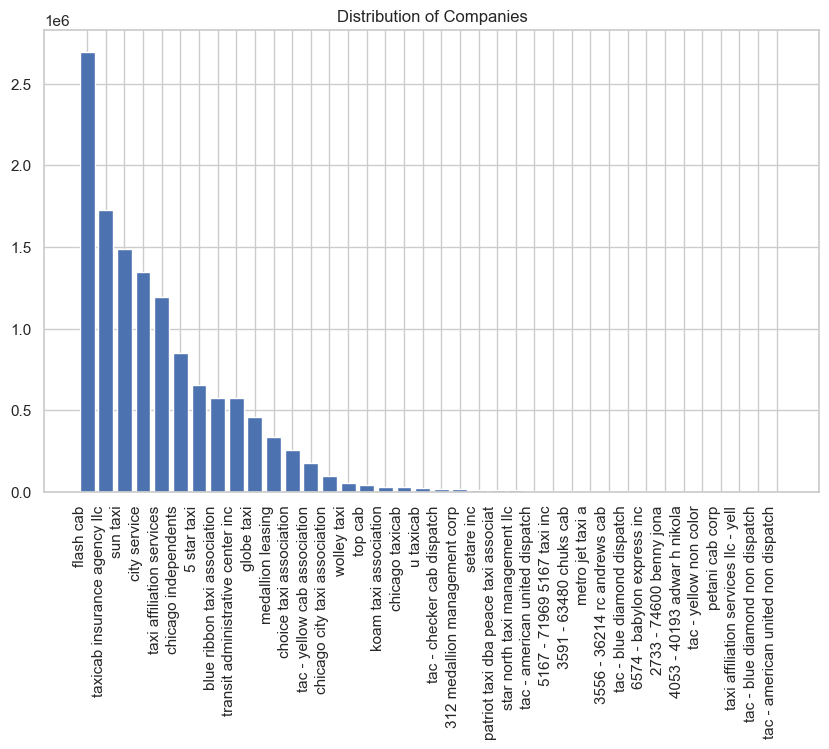

In [31]:
data = data.with_columns(
    pl.col("company")
    .str.to_lowercase()
    .str.strip_chars()
    .str.replace_all(r"\s+", " ", literal=False)
    .str.replace_all(r"[,\.]", "", literal=False)
)

# 2. Map the manual replacements
manual_mappings = {
    "choice taxi association inc": "choice taxi association",
    "blue ribbon taxi association inc": "blue ribbon taxi association",
    "top cab affiliation": "top cab",
    "medallion leasin": "medallion leasing",
}
data = data.with_columns(
    pl.col("company").replace(manual_mappings)
)

print(f"Unique companies: {data['company'].n_unique()}")

vc = data["company"].value_counts().sort("count", descending=True)
display(vc)

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style("whitegrid")
ax.bar(vc['company'], vc["count"])
plt.xticks(rotation=90, ha='right')
plt.title("Distribution of Companies")
plt.show()

# 8) Time features
For later usage we already define additional features here.

In [32]:
data = data.with_columns(
    pl.col("trip_start").dt.hour().cast(pl.Int8).alias("hour"),
    pl.col("trip_start").dt.weekday().cast(pl.Int8).alias("day_of_week"), # Polars Monday=1, Sunday=7 -> shift to 0-6
    pl.col("trip_start").dt.month().cast(pl.Int8).alias("month"),
    pl.col("trip_start").dt.date().alias("date")
).with_columns(    
    pl.col("day_of_week").is_in([6, 7]).alias("is_weekend"), # 6= Saturday, 7= Sunday

    pl.col("trip_start").dt.truncate("30m").alias("bin_30min"),
    pl.col("trip_start").dt.truncate("1h").alias("bin_1h"),
    pl.col("trip_start").dt.truncate("4h").alias("bin_4h"),
    pl.col("trip_start").dt.truncate("1d").alias("bin_1d"),
    pl.col("trip_start").dt.truncate("1w").alias("bin_1w"),
)

time_cols = ["trip_start", "hour", "day_of_week", "month", "date", "is_weekend",
             "bin_30min", "bin_1h", "bin_4h", "bin_1d", "bin_1w"]

print(f"Added {len(time_cols)} time columns.")

# Select columns and sample
display((data.select(time_cols).sample(n=10, seed=42)))

Added 11 time columns.


trip_start,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w
datetime[μs],i8,i8,i8,date,bool,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs]
2026-01-15 11:15:00,11,4,1,2026-01-15,false,2026-01-15 11:00:00,2026-01-15 11:00:00,2026-01-15 08:00:00,2026-01-15 00:00:00,2026-01-12 00:00:00
2025-11-01 17:30:00,17,6,11,2025-11-01,true,2025-11-01 17:30:00,2025-11-01 17:00:00,2025-11-01 16:00:00,2025-11-01 00:00:00,2025-10-27 00:00:00
2025-08-09 17:45:00,17,6,8,2025-08-09,true,2025-08-09 17:30:00,2025-08-09 17:00:00,2025-08-09 16:00:00,2025-08-09 00:00:00,2025-08-04 00:00:00
2024-12-30 10:00:00,10,1,12,2024-12-30,false,2024-12-30 10:00:00,2024-12-30 10:00:00,2024-12-30 08:00:00,2024-12-30 00:00:00,2024-12-30 00:00:00
2024-12-12 09:15:00,9,4,12,2024-12-12,false,2024-12-12 09:00:00,2024-12-12 09:00:00,2024-12-12 08:00:00,2024-12-12 00:00:00,2024-12-09 00:00:00
2024-09-24 07:30:00,7,2,9,2024-09-24,false,2024-09-24 07:30:00,2024-09-24 07:00:00,2024-09-24 04:00:00,2024-09-24 00:00:00,2024-09-23 00:00:00
2024-07-07 17:30:00,17,7,7,2024-07-07,true,2024-07-07 17:30:00,2024-07-07 17:00:00,2024-07-07 16:00:00,2024-07-07 00:00:00,2024-07-01 00:00:00
2024-06-18 19:45:00,19,2,6,2024-06-18,false,2024-06-18 19:30:00,2024-06-18 19:00:00,2024-06-18 16:00:00,2024-06-18 00:00:00,2024-06-17 00:00:00
2024-03-11 21:30:00,21,1,3,2024-03-11,false,2024-03-11 21:30:00,2024-03-11 21:00:00,2024-03-11 20:00:00,2024-03-11 00:00:00,2024-03-11 00:00:00


# 9) Cylcic encoding
For later usage in the prediction models we apply Cyclical Feature Encoding.

In [33]:
data = data.with_columns(
    (2 * np.pi * pl.col("hour") / 24).sin().alias("hour_sin"),
    (2 * np.pi * pl.col("hour") / 24).cos().alias("hour_cos"),
    (2 * np.pi * pl.col("day_of_week") / 7).sin().alias("dow_sin"),
    (2 * np.pi * pl.col("day_of_week") / 7).cos().alias("dow_cos"),
    (2 * np.pi * pl.col("month") / 12).sin().alias("month_sin"),
    (2 * np.pi * pl.col("month") / 12).cos().alias("month_cos"),
)

cyclic_cols = ["hour", "hour_sin", "hour_cos",
               "day_of_week", "dow_sin", "dow_cos",
               "month", "month_sin", "month_cos"]

print(f"Added 6 cyclic encoding columns.")

# Select columns and sample 10 rows
display(data.select(cyclic_cols).sample(n=10, seed=42))

Added 6 cyclic encoding columns.


hour,hour_sin,hour_cos,day_of_week,dow_sin,dow_cos,month,month_sin,month_cos
i8,f64,f64,i8,f64,f64,i8,f64,f64
11,0.258819,-0.965926,4,-0.433884,-0.900969,1,0.5,0.866025
17,-0.965926,-0.258819,6,-0.781831,0.62349,11,-0.5,0.866025
17,-0.965926,-0.258819,6,-0.781831,0.62349,8,-0.866025,-0.5
10,0.5,-0.866025,1,0.781831,0.62349,12,-2.4493e-16,1.0
9,0.707107,-0.707107,4,-0.433884,-0.900969,12,-2.4493e-16,1.0
7,0.965926,-0.258819,2,0.974928,-0.222521,9,-1.0,-1.8370e-16
17,-0.965926,-0.258819,7,-2.4493e-16,1.0,7,-0.5,-0.866025
19,-0.965926,0.258819,2,0.974928,-0.222521,6,1.2246e-16,-1.0
21,-0.707107,0.707107,1,0.781831,0.62349,3,1.0,6.1232e-17


# 10) Rest
Here are all other required operations stored.

In [34]:
data.head(1)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
str,str,datetime[μs],datetime[ms],duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str,f64,i8,i8,i8,date,bool,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00,2026-05-01 00:06:38,6m 38s,1.16,1.7031e10,1.7031e10,32.0,8.0,6.75,2.0,0.0,1.0,10.25,"""credit card""","""blue ribbon taxi association""",41.878866,-87.625192,"""POINT (-87.6251921424 41.87886…",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…",10.492462,0,5,5,2026-05-01,false,2026-05-01 00:00:00,2026-05-01 00:00:00,2026-05-01 00:00:00,2026-05-01 00:00:00,2026-04-27 00:00:00,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025


In [35]:
# Drop columns which are duplicate
data = data.drop('pickup_location', 'dropoff_location')
data.head(1)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
str,str,datetime[μs],datetime[ms],duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00,2026-05-01 00:06:38,6m 38s,1.16,1.7031e10,1.7031e10,32.0,8.0,6.75,2.0,0.0,1.0,10.25,"""credit card""","""blue ribbon taxi association""",41.878866,-87.625192,41.899602,-87.633308,10.492462,0,5,5,2026-05-01,false,2026-05-01 00:00:00,2026-05-01 00:00:00,2026-05-01 00:00:00,2026-05-01 00:00:00,2026-04-27 00:00:00,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025


# 11) Export

In [36]:
for stat in statistics:
    print(f"{stat[0]}: {stat[1]:,}")
print('Remaining rows after all cleaning steps: {:,}'.format(len(data)))

Original row count: 15,406,960
Removed rows with missing trip_seconds: 2,936
Removed rows with missing lat/lon: 424,044
Removed duplicate trip_id rows: 1,222,190
Removed extreme values: 1,041,850
Removed rows with trip_miles < 200 and trip_seconds < 3 hours: 10,884
Remaining rows after all cleaning steps: 12,701,771


In [ ]:
data.write_parquet('../data/01_cleaned_data.parquet')